# Benchmark visualizations — SCARSE against the baselines

SCARSE (ESM2 + GPR) compared against three baselines — physicochemical
descriptors, Morgan fingerprints and character n-grams, each with the same GPR —
across the three dataset families.

Per family: learning curves per dataset (mean ± 1 SD across seeds, drawn as
error bars dodged in x so overlapping models stay legible), and
below them the Tukey effect size of SCARSE minus each baseline, with
significance stars (* p ≤ 0.05, ** p ≤ 0.01, *** p ≤ 0.001). Red: SCARSE
better; blue: the baseline better. Empty cells were not testable.

The heatmap colour scale is fitted to the bulk of the effect sizes (the outlier
fence Q3 + 3·IQR of |effect|) and shared by the three heatmaps of a figure; the
few cells beyond it take the end colour, and the colour bar marks that with
arrows. Every cell is annotated with its true value.

Test R² axes are limited to [−1, 1]: R² cannot exceed 1, and a collapsed fit
(Test R² far below 0) would otherwise flatten every other curve in its panel.
Values below −1 run off the bottom of the panel. Spearman axes are limited to
[−1, 1] and top-20 accuracy axes to [0, 100].

Seed filter (figures only, set in `SEED_FILTERS`): for SDA BACSU with
Physchem + GPR, seeds with Test R² ≤ −10 are left out, in both substitutions
and indels and for every metric. The notebook prints which seeds were dropped.
The statistics heatmaps come from the statistics notebooks and are not filtered.

Reads the aggregated results written by *aggregate_simulation_results.py* and
the Tukey tables written by the statistics notebooks.

## Setup

In [1]:
import os
import string

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import AutoMinorLocator

# =========================
# Publication styling
# =========================
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 8.5,
    "axes.labelsize": 8,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 8,
    "text.color": INK,
    "axes.labelcolor": INK,
    # Black axes and black tick marks, matching the other notebooks.
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.labelcolor": INK,
    "ytick.labelcolor": INK,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "legend.frameon": False,
    "pdf.fonttype": 42,
})

#: Journal double-column width, in inches.
PAGE_WIDTH = 7.2

# =========================
# Representations
# =========================
#: Labels as stored in the results files. Do not change: the statistics
#: notebooks write these strings into their tables.
REPRESENTATION_LABELS = {
    "esm":      "GPR + ESM2",
    "physchem": "GPR + Physchem",
    "morgan":   "GPR + Morgan",
    "ngram":    "GPR + N-gram",
}
REFERENCE = "GPR + ESM2"
MODEL_ORDER = ["GPR + ESM2", "GPR + Physchem", "GPR + Morgan", "GPR + N-gram"]
BASELINES = [m for m in MODEL_ORDER if m != REFERENCE]

#: Seeds left out of the figures in this notebook (not of the statistics).
#: Each entry drops every seed of one dataset/representation whose `metric`
#: is at or below `min`; the whole seed is dropped, so all metrics (Test R2
#: and top-20 accuracy alike) are computed from the same remaining seeds.
#: `dataset` is the short name shown in the figures and matches in every family.
SEED_FILTERS = [
    {"dataset": "SDA BACSU", "model": "GPR + Physchem", "metric": "Test R2", "min": -10},
]

#: What the figures show. ESM2 + GPR is SCARSE, and every legend says so.
DISPLAY = {
    "GPR + ESM2":     "SCARSE (ESM2 + GPR)",
    "GPR + Physchem": "Physchem + GPR",
    "GPR + Morgan":   "Morgan + GPR",
    "GPR + N-gram":   "N-gram + GPR",
}
SHORT = {"GPR + Physchem": "Physchem", "GPR + Morgan": "Morgan", "GPR + N-gram": "N-gram"}

# Validated categorical palette: every pair separable under normal vision and
# the three colour-vision deficiencies. SCARSE keeps the blue it has in the
# foundation-model figures. Markers are the second channel.
COLORS = {
    "GPR + ESM2":     "#2a78d6",
    "GPR + Physchem": "#eb6834",
    "GPR + Morgan":   "#1baf7a",
    "GPR + N-gram":   "#4a3aa7",
}
MARKERS = {"GPR + ESM2": "o", "GPR + Physchem": "s", "GPR + Morgan": "^", "GPR + N-gram": "D"}

#: Diverging scale for SCARSE minus baseline: red = SCARSE better, blue = the
#: baseline better, neutral grey at zero.
EFFECT_CMAP = LinearSegmentedColormap.from_list(
    "scarse_diverging",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f4b1af", "#e34948", "#a8322f"],
)

#: Axis limits a metric can meaningfully take. Test R2 never exceeds 1, and the
#: floor of -1 stops a collapsed fit from flattening the other curves; an SD
#: band can reach beyond both, which is only an artefact of the spread.
Y_BOUNDS = {"Test R2": (-1.0, 1.0), "Test Spearman Correlation": (-1.0, 1.0),
            "Top 20 Accuracy": (0.0, 100.0)}

letters = list(string.ascii_lowercase)


def find_dir(*candidates, required=True):
    """Return the first of `candidates` that exists (relative to this notebook)."""
    for c in candidates:
        if os.path.isdir(c):
            print(f"Using {os.path.abspath(c)}")
            return c
    if required:
        raise FileNotFoundError("None of these folders exists:\n  "
                                + "\n  ".join(os.path.abspath(c) for c in candidates))
    print("Not found (figures will skip the statistics):\n  "
          + "\n  ".join(os.path.abspath(c) for c in candidates))
    return None


# The jobs write to simulate_experiments/simulation_output/; the other spellings
# are copies. The statistics notebooks may sit in either statistics/ folder.
SIM_ROOT = find_dir("./simulate_experiments/simulation_output",
                    "./simulation_output", "./simulation_outputs")
STATS_ROOT = find_dir("./statistics/results",
                      "./simulate_experiments/statistics/results", required=False)


def model_handles():
    return [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m], markersize=4.5,
                       markeredgecolor="white", markeredgewidth=0.6, linewidth=1.6,
                       label=DISPLAY[m]) for m in MODEL_ORDER]


def panel_letter(ax, i, dx=-26, dy=5):
    """Bold panel letter at the top-left, a fixed distance outside the axes.

    Only letters in the first grid column take part in the layout (they need
    room at the figure edge). Elsewhere the letter sits in the gap the tick
    labels already make, so it must not widen that gap.
    """
    t = ax.annotate(letters[i], xy=(0, 1), xycoords="axes fraction",
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=10, fontweight="bold", ha="left", va="bottom")
    ss = ax.get_subplotspec()
    t.set_in_layout(ss is None or ss.colspan.start == 0)


def fine_grid(ax):
    """Labelled gridlines plus a lighter unlabelled one between each pair, and
    visible black tick marks on both axes at each labelled value."""
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, axis="y", which="major")
    ax.grid(True, axis="y", which="minor", color=GRID, linewidth=0.4)
    ax.grid(False, axis="x")
    # Major tick marks on both axes (drawn here so they show regardless of the
    # rcParams state); minor ticks carry only the y gridline, no mark.
    ax.tick_params(axis="both", which="major", length=4.5, width=1.0,
                   direction="out", color=INK, bottom=True, left=True)
    ax.tick_params(axis="both", which="minor", length=0)


def fit_y(ax, metric):
    """Fit the y-axis to the data, within the range the metric can take."""
    ax.margins(x=0.04, y=0.10)
    lo, hi = ax.get_ylim()
    b_lo, b_hi = Y_BOUNDS.get(metric, (-np.inf, np.inf))
    lo, hi = max(lo, b_lo), min(hi, b_hi)
    if hi <= lo:                                  # everything outside the bounds
        lo, hi = b_lo, b_hi
    ax.set_ylim(lo, hi)


#: Horizontal offset per model, in x-position units, so the SD error bars of
#: models plotted at the same training size don't overlap and can be told apart.
DODGE_CAT = dict(zip(MODEL_ORDER, [-0.12, -0.04, 0.04, 0.12]))


def band_line(ax, x, y, spread, model):
    """Mean line with the ±1 SD drawn as error bars, dodged in x per model."""
    x = np.asarray(x, dtype=float) + DODGE_CAT.get(model, 0.0)
    y, spread = np.asarray(y, dtype=float), np.asarray(spread, dtype=float)
    ax.errorbar(x, y, yerr=spread, color=COLORS[model], marker=MARKERS[model],
                markersize=3.6, markeredgecolor="white", markeredgewidth=0.5,
                linewidth=1.4, capsize=1.8, elinewidth=0.7, capthick=0.7,
                zorder=4 if model == REFERENCE else 3)


def zero_line(ax):
    """Line at 0 when 0 is inside the data range; never widens the axis."""
    lo, hi = ax.get_ylim()
    if lo < 0 < hi:
        ax.axhline(0, color=AXIS, linewidth=0.8, zorder=1)
        ax.set_ylim(lo, hi)


def tight_layout_pads(fig):
    """Smaller gaps than matplotlib's constrained-layout defaults."""
    fig.get_layout_engine().set(w_pad=1 / 72, h_pad=1 / 72, wspace=0.01, hspace=0.01)


def save(fig, stem):
    fig.savefig(f"{stem}.png")
    fig.savefig(f"{stem}.pdf")
    print(f"Saved {stem}.png / .pdf")

Using /Users/leoan/Documents/GitHub/SCARSE-repro/code/benchmark/simulate_experiments/simulation_output
Using /Users/leoan/Documents/GitHub/SCARSE-repro/code/benchmark/simulate_experiments/statistics/results


In [2]:
# =========================
# Dataset names for panels and heatmap columns. The family is always clear from
# figure. The _sub / _ind family suffix is kept, space-separated.
# =========================
DATASET_SHORT = {
    "substitutions": {
        "A0A247D711_LISMN_Stadelmann_2021": "A0A247D711 LISMN",
        "DN7A_SACS2_Tsuboyama_2023_1JIC":   "DN7A SACS2",
        "ENVZ_ECOLI_Ghose_2023":            "ENVZ ECOLI",
        "FKBP3_HUMAN_Tsuboyama_2023_2KFV":  "FKBP3 HUMAN",
        "MAFG_MOUSE_Tsuboyama_2023_1K1V":   "MAFG MOUSE sub",
        "POLG_PESV_Tsuboyama_2023_2MXD":    "POLG PESV sub",
        "SBI_STAAM_Tsuboyama_2023_2JVG":    "SBI STAAM",
        "SDA_BACSU_Tsuboyama_2023_1PV0":    "SDA BACSU",
        "SOX30_HUMAN_Tsuboyama_2023_7JJK":  "SOX30 HUMAN",
        "YNZC_BACSU_Tsuboyama_2023_2JVD":   "YNZC BACSU sub",
    },
    "indels": {
        "PKN1_HUMAN_Tsuboyama_2023_1URF_indels":  "PKN1 HUMAN",
        "RPC1_BP434_Tsuboyama_2023_1R69_indels":  "RPC1 BP434",
        "POLG_PESV_Tsuboyama_2023_2MXD_indels":   "POLG PESV ind",
        "SDA_BACSU_Tsuboyama_2023_1PV0_indels":   "SDA BACSU ind",
        "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels": "RD23A HUMAN",
        "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels":  "MAFG MOUSE ind",
        "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels": "SQSTM MOUSE",
        "VG08_BPP22_Tsuboyama_2023_2GP8_indels":  "VG08 BPP22",
        "YNZC_BACSU_Tsuboyama_2023_2JVD_indels":  "YNZC BACSU ind",
        "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels":  "PIN1 HUMAN",
    },
    "peptides": {
        "EC_all_40":   r"$\it{E.\ coli}$ AMPs",
        "SA_all_40":   r"$\it{S.\ aureus}$ AMPs",
        "PA_all_40":   r"$\it{P.\ aeruginosa}$ AMPs",
        "hemopi2_all": "HemoPI2",
    },
}

FAMILY_TITLE = {"substitutions": "Substitutions", "indels": "Indels", "peptides": "Peptides"}

## Process results

In [3]:
def process_data(family, sim_root=SIM_ROOT):
    """Attach a representation label to each aggregated result row."""
    csv_path = os.path.join(sim_root, family)
    df = pd.read_csv(os.path.join(csv_path, "simulation_summary.csv"))

    numeric_cols = [c for c in df.columns if c.endswith(" Mean") or c.endswith(" Std")]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.loc[df["Model"] == "GaussianProcessRegressor", "Model"] = "GPR"

    unknown = set(df["Representation"].unique()) - set(REPRESENTATION_LABELS)
    if unknown:
        raise ValueError(f"Unexpected representations in {family}: {sorted(unknown)}")

    df["Model Label"] = df["Representation"].map(REPRESENTATION_LABELS)

    out = os.path.join(csv_path, "simulation_summary_processed.csv")
    df.to_csv(out, index=False)
    print(f"{family}: {len(df)} rows, representations "
          f"{sorted(df['Model Label'].unique())}")
    return df


for family in ["substitutions", "indels", "peptides"]:
    process_data(family)

substitutions: 280 rows, representations ['GPR + ESM2', 'GPR + Morgan', 'GPR + N-gram', 'GPR + Physchem']
indels: 160 rows, representations ['GPR + ESM2', 'GPR + Morgan', 'GPR + N-gram', 'GPR + Physchem']
peptides: 112 rows, representations ['GPR + ESM2', 'GPR + Morgan', 'GPR + N-gram', 'GPR + Physchem']


## Plotting helpers

In [4]:
_filter_reported = set()


def filtered_seed_stats(family, metric, sim_root=SIM_ROOT):
    """Mean and SD of `metric` for the groups hit by SEED_FILTERS, recomputed from
    the per-seed results (simulation_summary_all.csv) without the filtered seeds.
    """
    short = DATASET_SHORT.get(family, {})
    active = [f for f in SEED_FILTERS if f["dataset"] in short.values()]
    if not active:
        return None
    path = os.path.join(sim_root, family, "simulation_summary_all.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"SEED_FILTERS needs the per-seed results, but {path} does not exist. "
            "It is written by aggregate_simulation_results.py next to simulation_summary.csv.")
    runs = pd.read_csv(path)
    runs["Model Label"] = runs["Representation"].map(REPRESENTATION_LABELS)
    runs["Short"] = runs["Dataset"].map(lambda d: short.get(d, d))

    parts = []
    for f in active:
        g = runs[(runs["Short"] == f["dataset"]) & (runs["Model Label"] == f["model"])]
        keep = pd.to_numeric(g[f["metric"]], errors="coerce") > f["min"]
        key = (family, f["dataset"], f["model"])
        if key not in _filter_reported:
            _filter_reported.add(key)
            dropped = g.loc[~keep, ["Train Size", "Seed", f["metric"]]]
            print(f"[seed filter] {family} / {f['dataset']} / {DISPLAY[f['model']]}: "
                  f"dropped {len(dropped)} of {len(g)} seed runs with {f['metric']} <= {f['min']}")
            for _, r in dropped.sort_values(["Train Size", "Seed"]).iterrows():
                print(f"    train size {int(r['Train Size'])}, seed {int(r['Seed'])}: "
                      f"{f['metric']} = {r[f['metric']]:.3g}")
        parts.append(g[keep])
    kept = pd.concat(parts)
    return (kept.groupby(["Dataset", "Model Label", "Train Size"], as_index=False)[metric]
                .agg(mean="mean", std="std"))


def load_processed(family, metric, sim_root=SIM_ROOT):
    """Mean and SD (across seeds) of `metric` per dataset, representation and train size.

    Groups listed in SEED_FILTERS are recomputed without the filtered seeds.
    """
    df = pd.read_csv(os.path.join(sim_root, family, "simulation_summary_processed.csv"))
    df = df[df["Model Label"].isin(MODEL_ORDER)]
    out = (df.groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
             .agg(mean=(f"{metric} Mean", "mean"), std=(f"{metric} Std", "mean")))
    fixed = filtered_seed_stats(family, metric, sim_root)
    if fixed is not None:
        keys = ["Dataset", "Model Label", "Train Size"]
        hit = out.set_index(keys).index.isin(fixed.set_index(keys).index)
        out = pd.concat([out[~hit], fixed], ignore_index=True)
    return out


def significance_stars(p):
    if pd.isna(p):
        return ""
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return ""


def load_stats(family, metric, baseline, stats_root=STATS_ROOT):
    """Tukey effect size of SCARSE minus `baseline`, with significance stars.

    The statistics notebooks store all six pairwise comparisons, in either order,
    so the pair is selected explicitly and the sign normalised: positive always
    means SCARSE scored higher.
    """
    if stats_root is None:
        return None
    path = os.path.join(stats_root, f"{family}_results.csv")
    if not os.path.exists(path):
        print(f"Missing statistics (run the {family} statistics notebook): {path}")
        return None

    stats = pd.read_csv(path)
    stats = stats[stats["Metric"] == metric].copy()
    pair = stats[((stats["group1"] == REFERENCE) & (stats["group2"] == baseline)) |
                 ((stats["group1"] == baseline) & (stats["group2"] == REFERENCE))].copy()
    if pair.empty:
        return None

    flip = pair["group1"] == baseline
    pair.loc[flip, "effect size"] = -pair.loc[flip, "effect size"]
    pair["signif"] = pair["p-adj"].apply(significance_stars)
    return pair


def draw_curves(ax, df, dataset, train_sizes, metric):
    """One dataset: every representation against training size, mean ± 1 SD across seeds."""
    x = np.arange(len(train_sizes))
    for model in MODEL_ORDER:
        d = (df[(df["Dataset"] == dataset) & (df["Model Label"] == model)]
             .set_index("Train Size").reindex(train_sizes))
        if d["mean"].isna().all():
            continue
        band_line(ax, x, d["mean"].values, d["std"].values, model)
    ax.set_xticks(x)
    ax.set_xticklabels(train_sizes)
    fine_grid(ax)
    fit_y(ax, metric)
    zero_line(ax)


def fmt_effect(v):
    """Compact annotation that fits a heatmap cell whatever the magnitude."""
    if pd.isna(v):
        return ""
    if abs(v) >= 10:
        return f"{v:.0f}"
    if abs(v) >= 1:
        return f"{v:.1f}"
    return f"{v:.2f}" if round(v, 2) != 0 else "0.00"


def robust_limit(values, k=3.0):
    """Colour-scale limit from the bulk of |effect|, so a few extreme cells cannot
    wash out everything else: the outlier fence Q3 + k*IQR of |effect|, never
    beyond the largest value. Unlike a percentile, it ignores the extremes
    however many of them there are. Rounded up to a clean number."""
    v = np.abs(np.asarray(values, dtype=float))
    v = v[np.isfinite(v)]
    if v.size == 0:
        return 1.0, False
    q1, q3 = np.percentile(v, [25, 75])
    lim = min(q3 + k * (q3 - q1), v.max())
    if lim <= 0:
        lim = v.max() if v.max() > 0 else 1.0
    step = 10 ** np.floor(np.log10(lim))
    lim = np.ceil(lim / step * 2) / 2 * step       # 1, 1.5, 2, 2.5 ... x 10^k
    return float(lim), bool(v.max() > lim)

In [5]:
def plot_metric_grid(family, metric, ylabel, n_cols=2, curve_h=1.15, heat_row_h=0.12):
    """Portrait figure: per-dataset curves above, SCARSE-minus-baseline heatmaps below."""
    df = load_processed(family, metric)
    short = DATASET_SHORT.get(family, {})
    datasets = sorted(df["Dataset"].unique(), key=lambda d: short.get(d, d))
    train_sizes = sorted(df["Train Size"].unique())

    pairs = {b: load_stats(family, metric, b) for b in BASELINES}
    pairs = {b: p for b, p in pairs.items() if p is not None}

    n_rows = int(np.ceil(len(datasets) / n_cols))
    heat_h = heat_row_h * len(train_sizes) + 0.22
    n_heat = len(pairs)
    fig = plt.figure(layout="constrained",
                     figsize=(PAGE_WIDTH, curve_h * n_rows + heat_h * n_heat + 0.75))
    tight_layout_pads(fig)
    gs = fig.add_gridspec(n_rows + n_heat, n_cols,
                          height_ratios=[curve_h] * n_rows + [heat_h] * n_heat)

    # ---------------- learning curves ----------------
    k = 0
    for i, dataset in enumerate(datasets):
        r, c = divmod(i, n_cols)
        ax = fig.add_subplot(gs[r, c])
        draw_curves(ax, df, dataset, train_sizes, metric)
        ax.set_title(short.get(dataset, dataset), pad=3)
        if c == 0:
            ax.set_ylabel(ylabel)
        if i + n_cols >= len(datasets):              # nothing below this panel
            ax.set_xlabel("Training set size")
        panel_letter(ax, k)
        k += 1

    # ---------------- heatmaps: one shared, robust colour scale ----------------
    if pairs:
        cols = [d for d in datasets]
        grids = {}
        for b, pair in pairs.items():
            eff = pair.pivot_table(index="Train Size", columns="Dataset", values="effect size")
            sig = pair.pivot_table(index="Train Size", columns="Dataset", values="signif",
                                   aggfunc="first")
            eff = eff.reindex(index=train_sizes, columns=cols)
            sig = sig.reindex(index=train_sizes, columns=cols)
            grids[b] = (eff, sig)

        lim, clipped = robust_limit(np.concatenate([e.values.ravel() for e, _ in grids.values()]))
        norm = Normalize(vmin=-lim, vmax=lim)

        heat_axes = []
        for j, (b, (eff, sig)) in enumerate(grids.items()):
            ax = fig.add_subplot(gs[n_rows + j, :])
            annot = eff.map(fmt_effect) + sig.fillna("")
            last = j == len(grids) - 1               # dataset names only on the last
            sns.heatmap(eff.clip(-lim, lim), ax=ax, cmap=EFFECT_CMAP, norm=norm,
                        annot=annot.values, fmt="", cbar=False,
                        linewidths=0.6, linecolor="white",
                        annot_kws={"fontsize": 5.4},
                        # Two-line names only where columns are narrow.
                        xticklabels=[short.get(d, d).replace(" ", "\n", 1)
                                     if len(cols) > 5 else short.get(d, d) for d in cols]
                                    if last else False,
                        yticklabels=[str(t) for t in train_sizes])
            ax.grid(False)
            ax.set_title(f"SCARSE − {SHORT[b]} + GPR", loc="left", fontsize=7.5, pad=2)
            if j == 0:     # say once what the rows are; an axis label would not fit
                ax.set_title("rows: training set size", loc="right", fontsize=6.5,
                             color=MUTED, pad=2)
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="both", length=0)
            ax.tick_params(axis="y", rotation=0)
            if last:
                plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=6.6,
                         linespacing=1.0)
            panel_letter(ax, k, dy=2)
            k += 1
            heat_axes.append(ax)

    fig.legend(handles=model_handles(), loc="outside upper center",
               ncol=len(MODEL_ORDER), columnspacing=1.4, handletextpad=0.4)

    if pairs:
        # Colour bar to the right of the heatmaps, ending exactly where the curve
        # panels end: lay the figure out first, freeze it, then make room for the
        # colour bar by narrowing the heatmaps only.
        fig.canvas.draw()
        fig.set_layout_engine("none")
        right = max(a.get_position().x1 for a in fig.axes if a not in heat_axes)
        top, bottom = heat_axes[0].get_position().y1, heat_axes[-1].get_position().y0
        cb_w, gap = 0.014, 0.012
        cax = fig.add_axes([right - cb_w, bottom, cb_w, top - bottom])
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=EFFECT_CMAP)
        cbar = fig.colorbar(sm, cax=cax, extend="both" if clipped else "neither")
        cbar.set_label(f"{ylabel}, SCARSE − baseline", fontsize=7, labelpad=2)
        cbar.ax.tick_params(labelsize=6.5, length=0, pad=1.5)
        cbar.outline.set_visible(False)
        # Shift the bar left until its tick labels and title end at `right`.
        fig.canvas.draw()
        inv = fig.transFigure.inverted()
        overhang = inv.transform(cax.get_tightbbox().extents.reshape(2, 2))[1, 0] - right
        x0 = right - cb_w - overhang
        cax.set_position([x0, bottom, cb_w, top - bottom])
        for a in heat_axes:
            p = a.get_position()
            a.set_position([p.x0, p.y0, x0 - gap - p.x0, p.height])
    tag = metric.lower().replace(" ", "_").replace("test_", "")
    save(fig, f"benchmark_{family}_{tag}")
    plt.show()
    return fig

## Substitutions

[seed filter] substitutions / SDA BACSU / Physchem + GPR: dropped 5 of 70 seed runs with Test R2 <= -10
    train size 50, seed 46: Test R2 = -126
    train size 50, seed 47: Test R2 = -33.6
    train size 75, seed 42: Test R2 = -100
    train size 75, seed 50: Test R2 = -312
    train size 100, seed 42: Test R2 = -27.4
Saved benchmark_substitutions_r2.png / .pdf


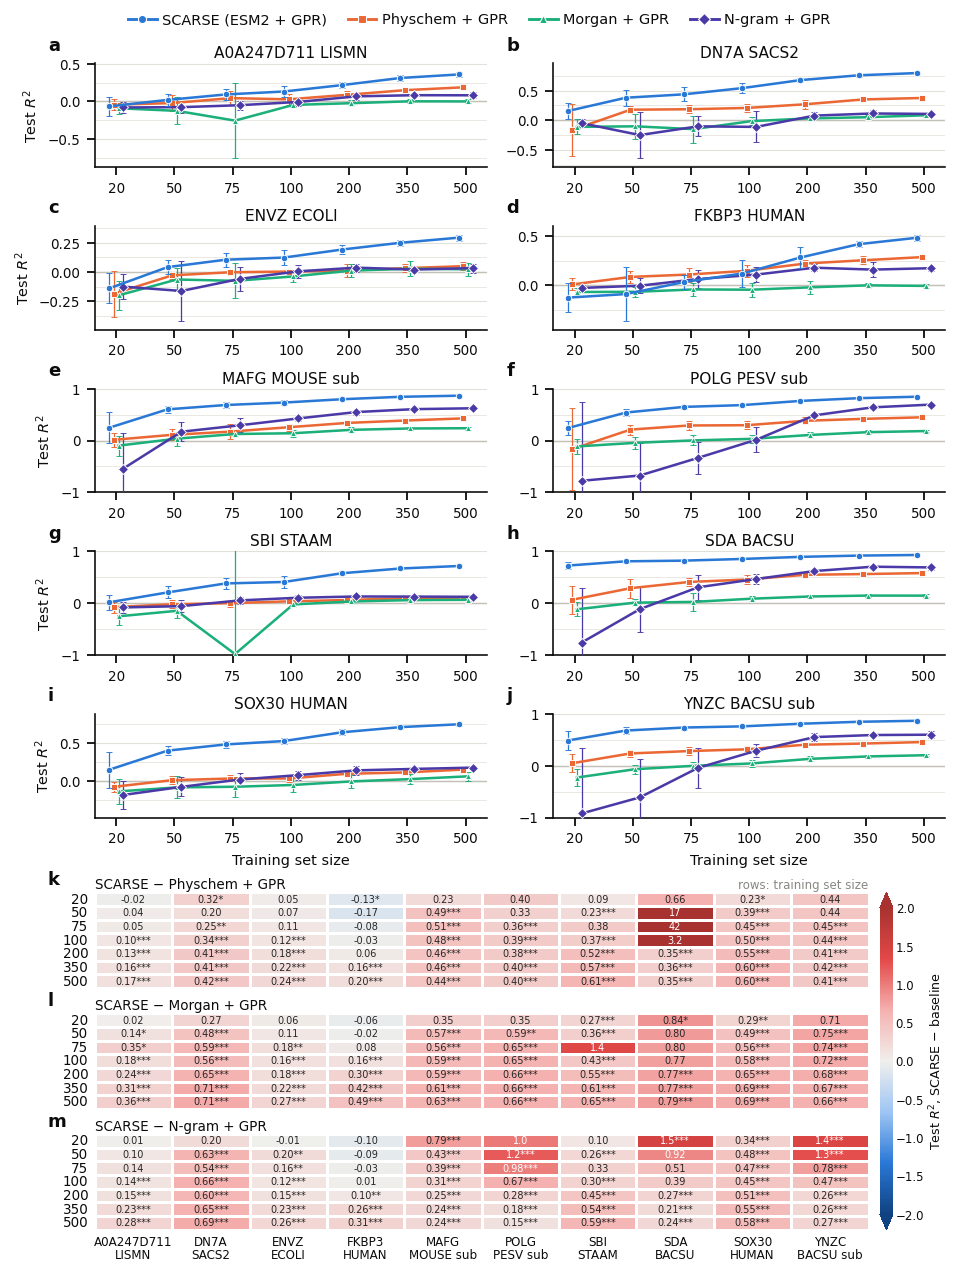

In [6]:
_ = plot_metric_grid("substitutions", "Test R2", r"Test $R^2$")

In [7]:
# =========================================================================
# Fig. E1 value dump — every plotted number, straight from the same functions
# the figure uses (load_processed / load_stats), so the seed-filter recompute
# is included. Panels a-j: SCARSE and the three baselines, Test R2 mean +/- std
# across seeds at each training size. Panels k-m: SCARSE - baseline effect size
# with Tukey significance stars.
# =========================================================================
def dump_fig_e1(family="substitutions", metric="Test R2"):
    short = DATASET_SHORT.get(family, {})
    proc  = load_processed(family, metric)
    train_sizes = sorted(proc["Train Size"].unique())
    datasets = sorted(proc["Dataset"].unique(), key=lambda d: short.get(d, d))

    panel = dict(zip(datasets, letters))   # a, b, c, ... in the same sorted order

    print("=" * 78)
    print(f"Fig. E1  —  {family}, {metric}   (mean +/- std across seeds)")
    print("=" * 78)

    # ---- panels a-j: the learning curves ----
    for dataset in datasets:
        print(f"\n({panel[dataset]}) {short.get(dataset, dataset)}   [{dataset}]")
        header = "    " + "".join(f"{('n='+str(t)):>14}" for t in train_sizes)
        print(header)
        for model in MODEL_ORDER:
            d = (proc[(proc["Dataset"] == dataset) & (proc["Model Label"] == model)]
                 .set_index("Train Size").reindex(train_sizes))
            if d["mean"].isna().all():
                continue
            cells = []
            for t in train_sizes:
                m, s = d.loc[t, "mean"], d.loc[t, "std"]
                cells.append("      n/a     " if pd.isna(m) else f"{m:6.3f}+/-{s:5.3f}")
            print(f"  {DISPLAY[model]:<22}" + "".join(f"{c:>14}" for c in cells))

    # ---- panels k-m: SCARSE - baseline effect size + significance ----
    stats_ok = STATS_ROOT is not None
    print("\n" + "=" * 78)
    print("Panels k-m: effect size (SCARSE - baseline), Tukey HSD stars "
          "(* p<=.05, ** p<=.01, *** p<=.001)")
    print("=" * 78)
    if not stats_ok:
        print("  STATS_ROOT is None — statistics not available in this copy, "
              "so panels k-m cannot be printed.")
    else:
        heat_letter = iter([l for l in letters[len(datasets):]])
        for b in BASELINES:
            pair = load_stats(family, metric, b)
            print(f"\n({next(heat_letter)}) SCARSE - {SHORT[b]} + GPR")
            if pair is None or pair.empty:
                print("    (no statistics rows for this pair)")
                continue
            eff = pair.pivot_table(index="Train Size", columns="Dataset", values="effect size")
            sig = pair.pivot_table(index="Train Size", columns="Dataset", values="signif",
                                   aggfunc="first")
            cols = [d for d in datasets if d in eff.columns]
            print("    train size |  " + "  ".join(f"{short.get(d,d):>16}" for d in cols))
            for t in train_sizes:
                if t not in eff.index:
                    continue
                row = []
                for d in cols:
                    v = eff.loc[t, d] if d in eff.columns else float("nan")
                    star = sig.loc[t, d] if (d in sig.columns and t in sig.index) else ""
                    row.append("           n/a  " if pd.isna(v) else f"{v:>12.3f}{star:<4}")
                print(f"    {t:>10} |  " + "  ".join(f"{c:>16}" for c in row))

    print("\n" + "=" * 78)
    print("Notes:")
    print(" - Values come from load_processed()/load_stats(), the same source the")
    print("   figure draws from, so any SEED_FILTERS recompute is already applied.")
    print(" - SCARSE = GPR + ESM2. Panel letters match the figure's a-j (curves)")
    print("   and k-m (heatmaps), in the same dataset sort order.")
    print("=" * 78)


dump_fig_e1("substitutions", "Test R2")


Fig. E1  —  substitutions, Test R2   (mean +/- std across seeds)

(a) A0A247D711 LISMN   [A0A247D711_LISMN_Stadelmann_2021]
              n=20          n=50          n=75         n=100         n=200         n=350         n=500
  SCARSE (ESM2 + GPR)   -0.065+/-0.124 0.021+/-0.081 0.093+/-0.075 0.132+/-0.073 0.217+/-0.045 0.311+/-0.041 0.358+/-0.032
  Physchem + GPR        -0.042+/-0.070-0.021+/-0.104 0.045+/-0.090 0.029+/-0.075 0.088+/-0.045 0.150+/-0.034 0.188+/-0.028
  Morgan + GPR          -0.090+/-0.070-0.124+/-0.180-0.254+/-0.500-0.045+/-0.028-0.023+/-0.036 0.002+/-0.027 0.001+/-0.026
  N-gram + GPR          -0.079+/-0.075-0.075+/-0.074-0.049+/-0.058-0.006+/-0.047 0.068+/-0.049 0.083+/-0.013 0.082+/-0.037

(b) DN7A SACS2   [DN7A_SACS2_Tsuboyama_2023_1JIC]
              n=20          n=50          n=75         n=100         n=200         n=350         n=500
  SCARSE (ESM2 + GPR)    0.155+/-0.135 0.381+/-0.132 0.438+/-0.119 0.543+/-0.082 0.679+/-0.038 0.760+/-0.021 0.798+/-0.017
  Ph

Saved benchmark_substitutions_spearman_correlation.png / .pdf


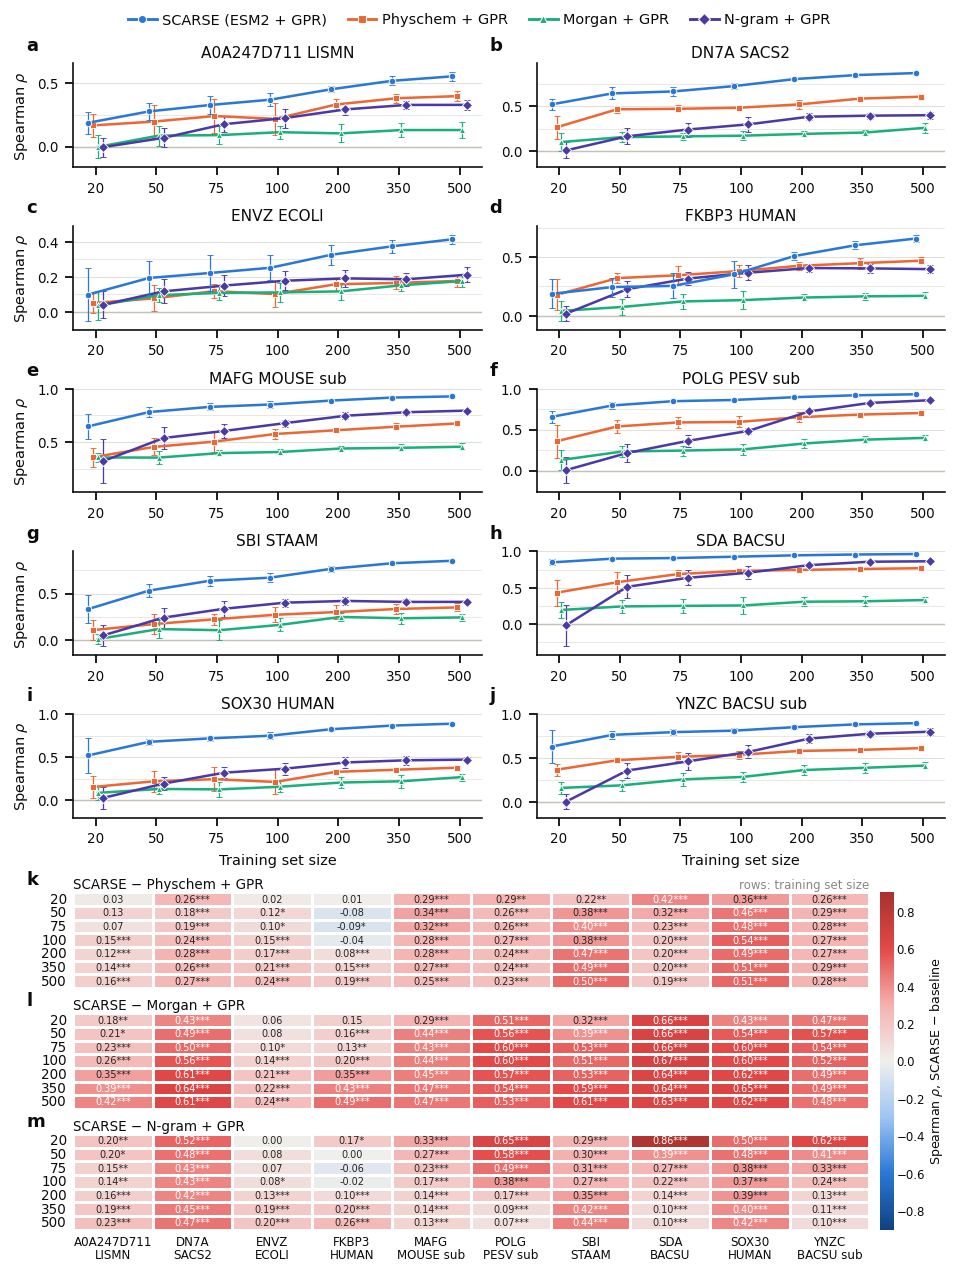

In [8]:
_ = plot_metric_grid("substitutions", "Test Spearman Correlation", r"Spearman $\rho$")

### Substitutions — top 20 accuracy

How often the 20 highest-predicted sequences are genuinely in the true top 20.

Saved benchmark_substitutions_top_20_accuracy.png / .pdf


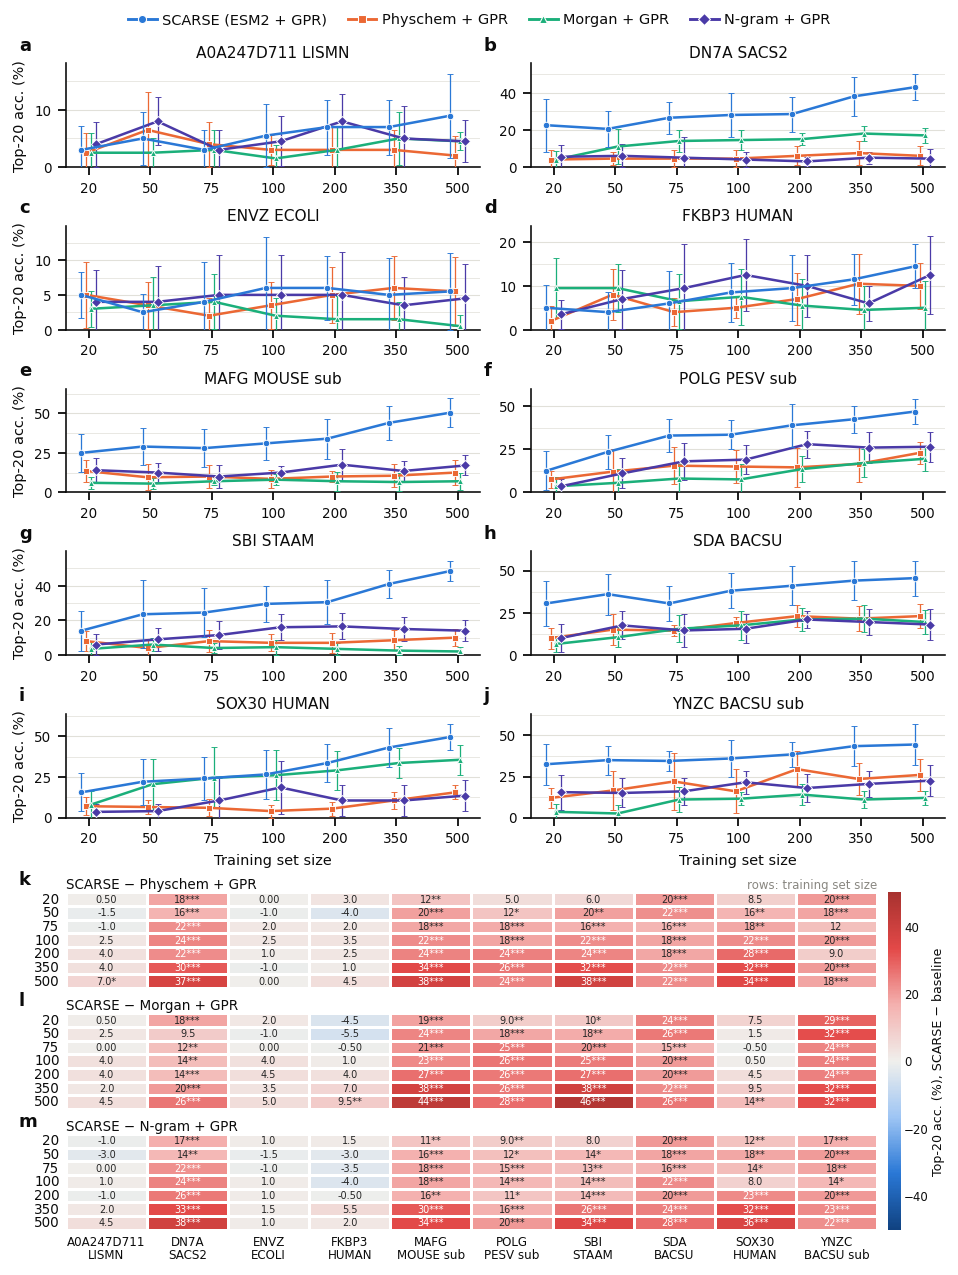

In [9]:
_ = plot_metric_grid("substitutions", "Top 20 Accuracy", "Top-20 acc. (%)")

## Indels

Saved benchmark_indels_r2.png / .pdf


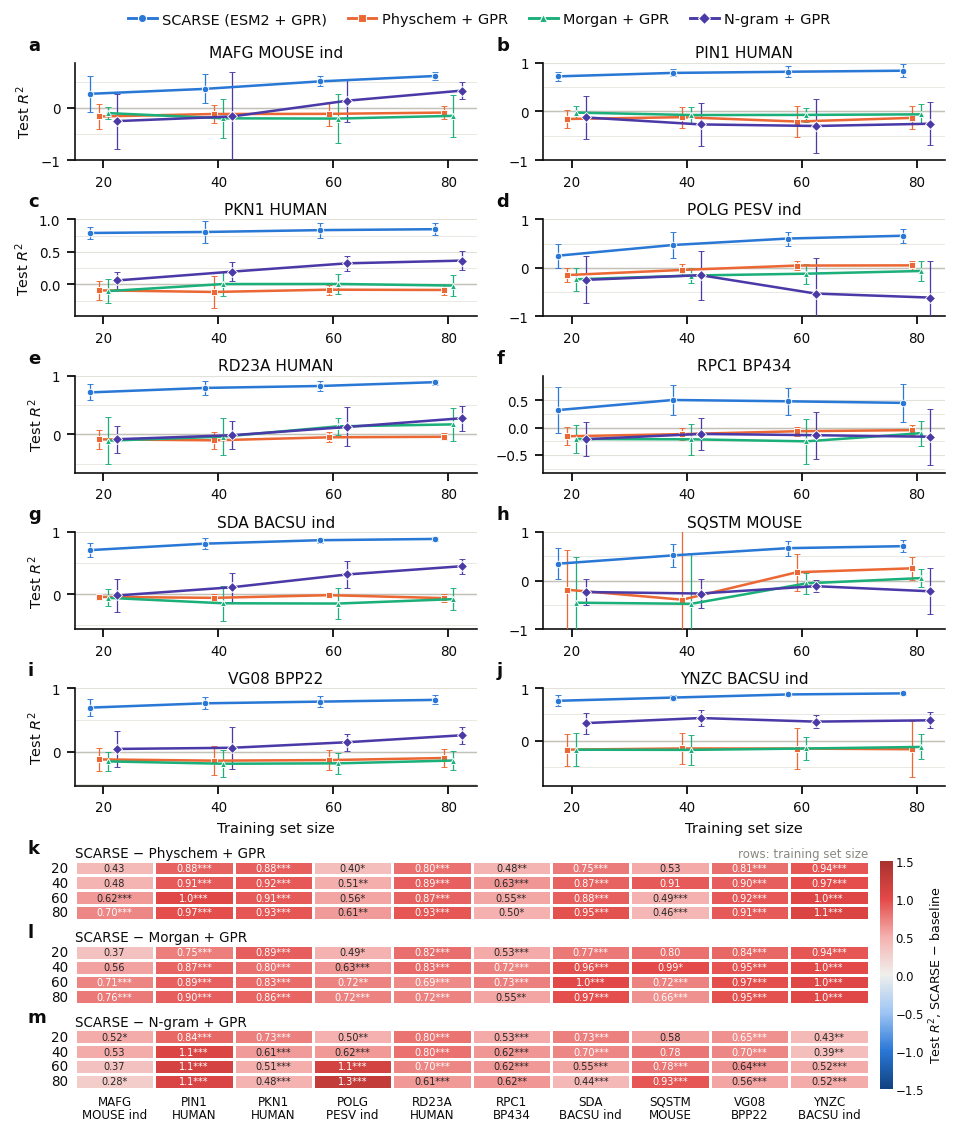

In [10]:
_ = plot_metric_grid("indels", "Test R2", r"Test $R^2$")

Saved benchmark_indels_spearman_correlation.png / .pdf


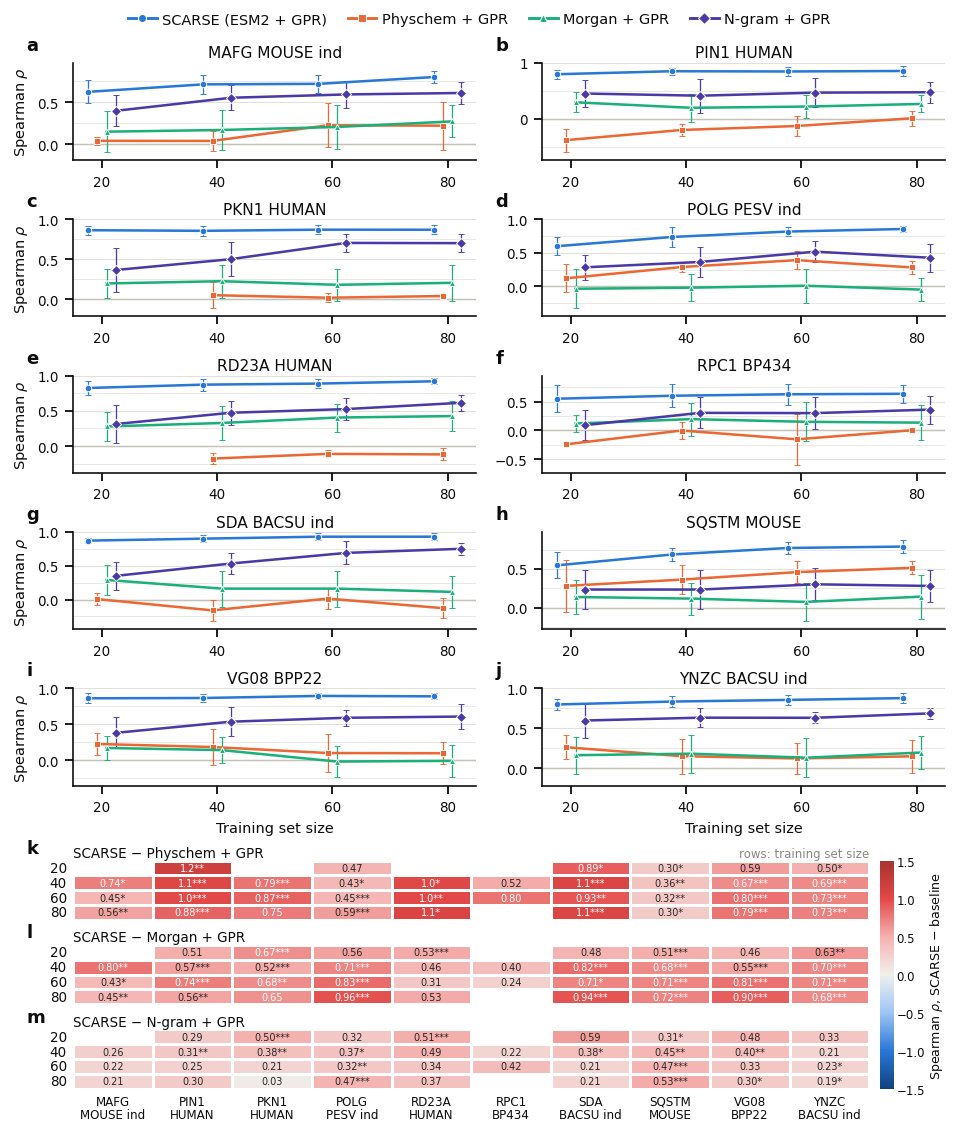

In [11]:
_ = plot_metric_grid("indels", "Test Spearman Correlation", r"Spearman $\rho$")

### Indels — top 20 accuracy

How often the 20 highest-predicted sequences are genuinely in the true top 20.

Saved benchmark_indels_top_20_accuracy.png / .pdf


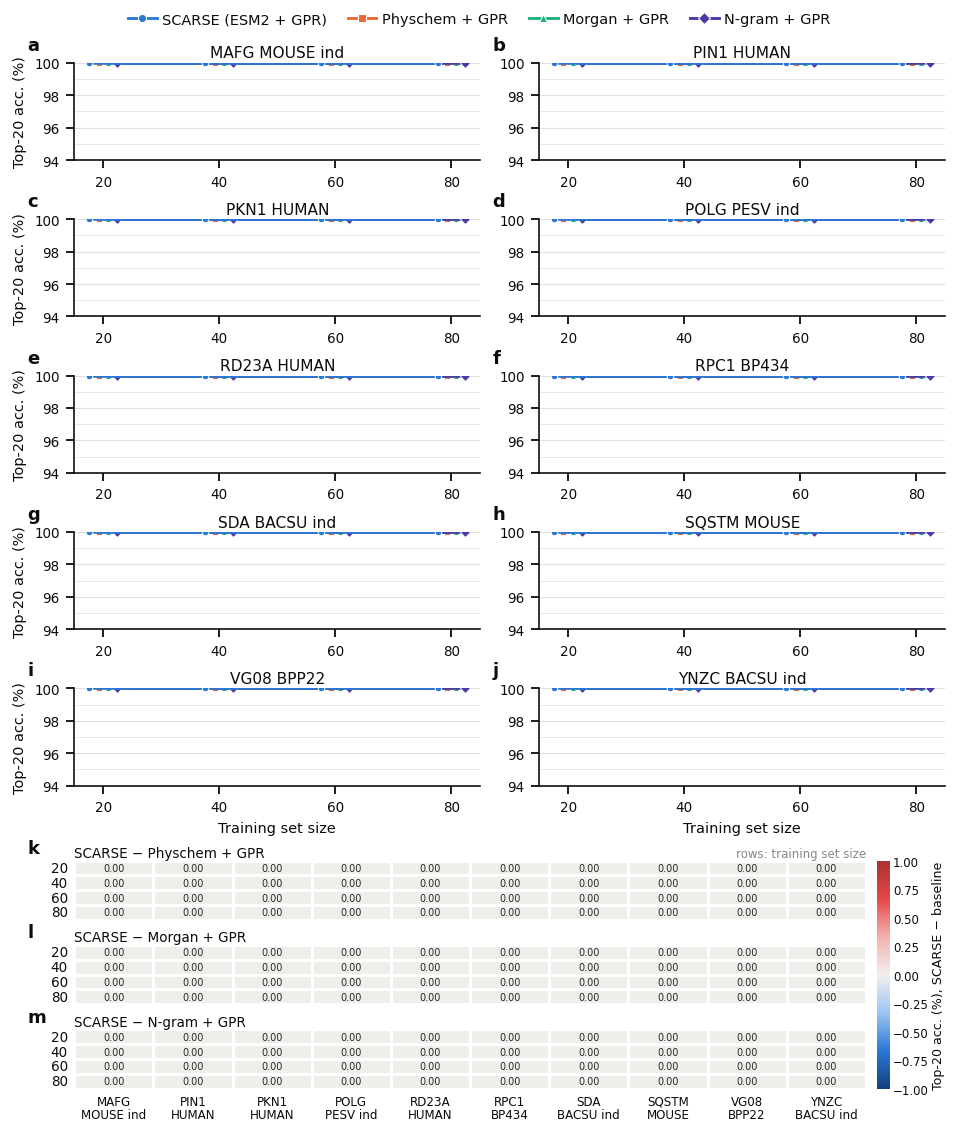

In [12]:
_ = plot_metric_grid("indels", "Top 20 Accuracy", "Top-20 acc. (%)")

## Peptides

Saved benchmark_peptides_r2.png / .pdf


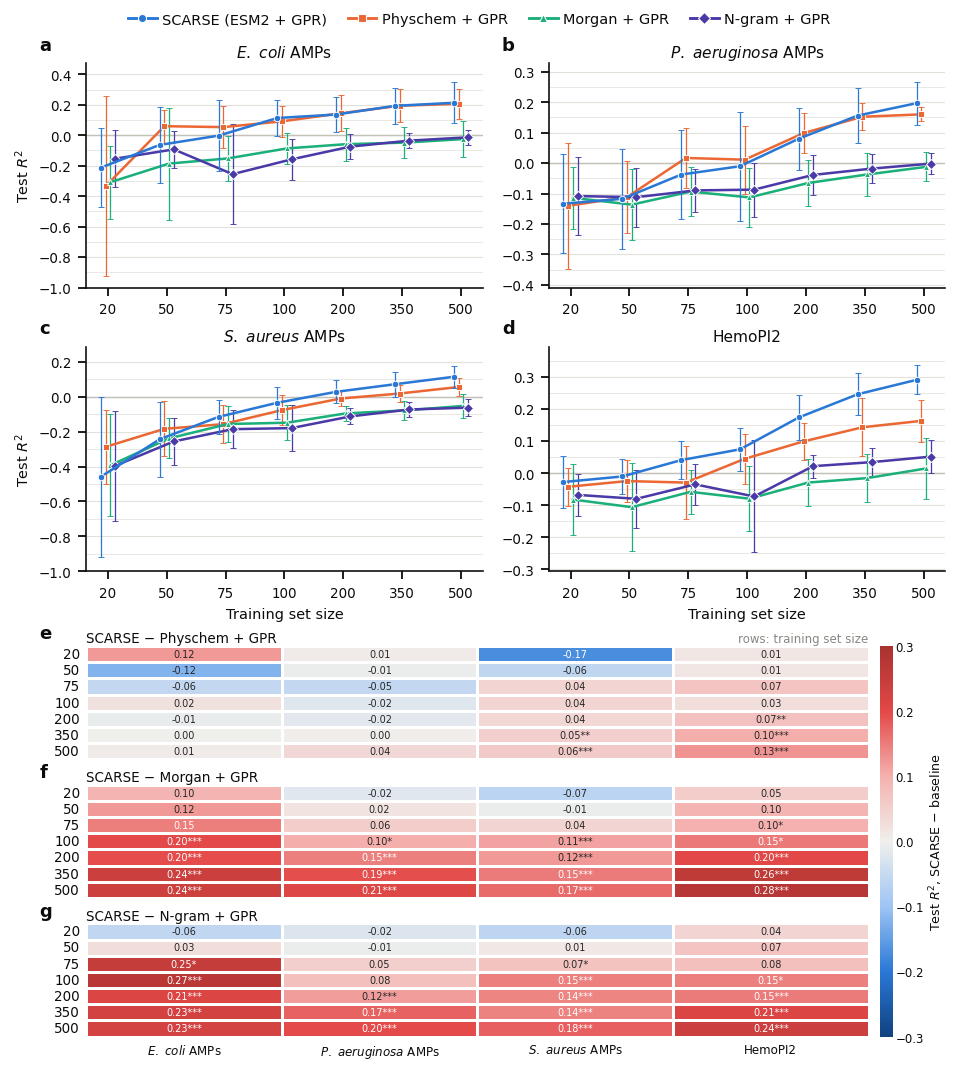

In [13]:
_ = plot_metric_grid("peptides", "Test R2", r"Test $R^2$", curve_h=2.1)

Saved benchmark_peptides_spearman_correlation.png / .pdf


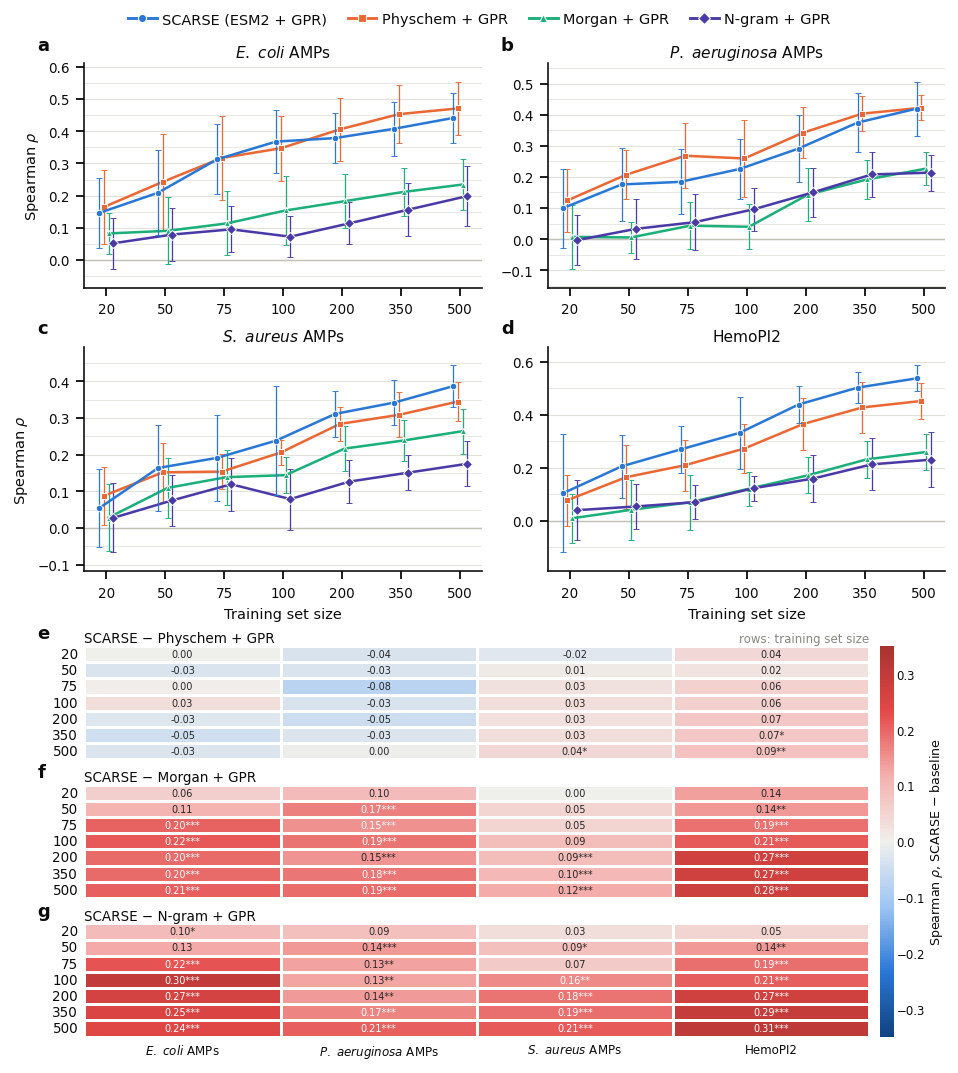

In [14]:
_ = plot_metric_grid("peptides", "Test Spearman Correlation", r"Spearman $\rho$", curve_h=2.1)

### Peptides — top 20 accuracy

How often the 20 highest-predicted sequences are genuinely in the true top 20.

Saved benchmark_peptides_top_20_accuracy.png / .pdf


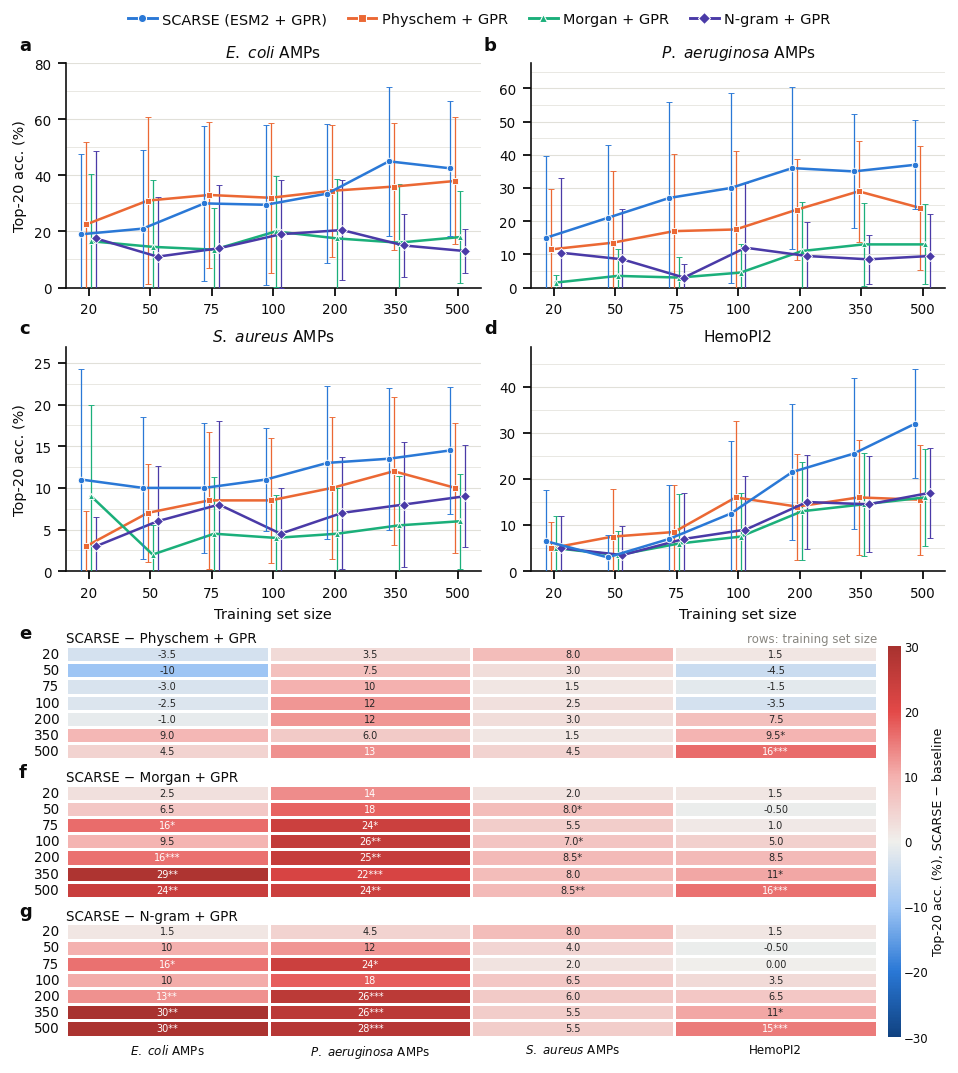

In [15]:
_ = plot_metric_grid("peptides", "Top 20 Accuracy", "Top-20 acc. (%)", curve_h=2.1)

## Summary across families

Substitutions and indels get one row each. **Left:** mean across the family's
datasets, error bars ±1 SD across datasets. **Middle / right:** the dataset on
which SCARSE does best and worst on average (its mean over all training sizes),
error bars ±1 SD across seeds. **Peptides:** every dataset in its own panel,
error bars ±1 SD across seeds.

Saved as *benchmark_results.png* and *benchmark_results.pdf*.

Saved benchmark_results.png / .pdf


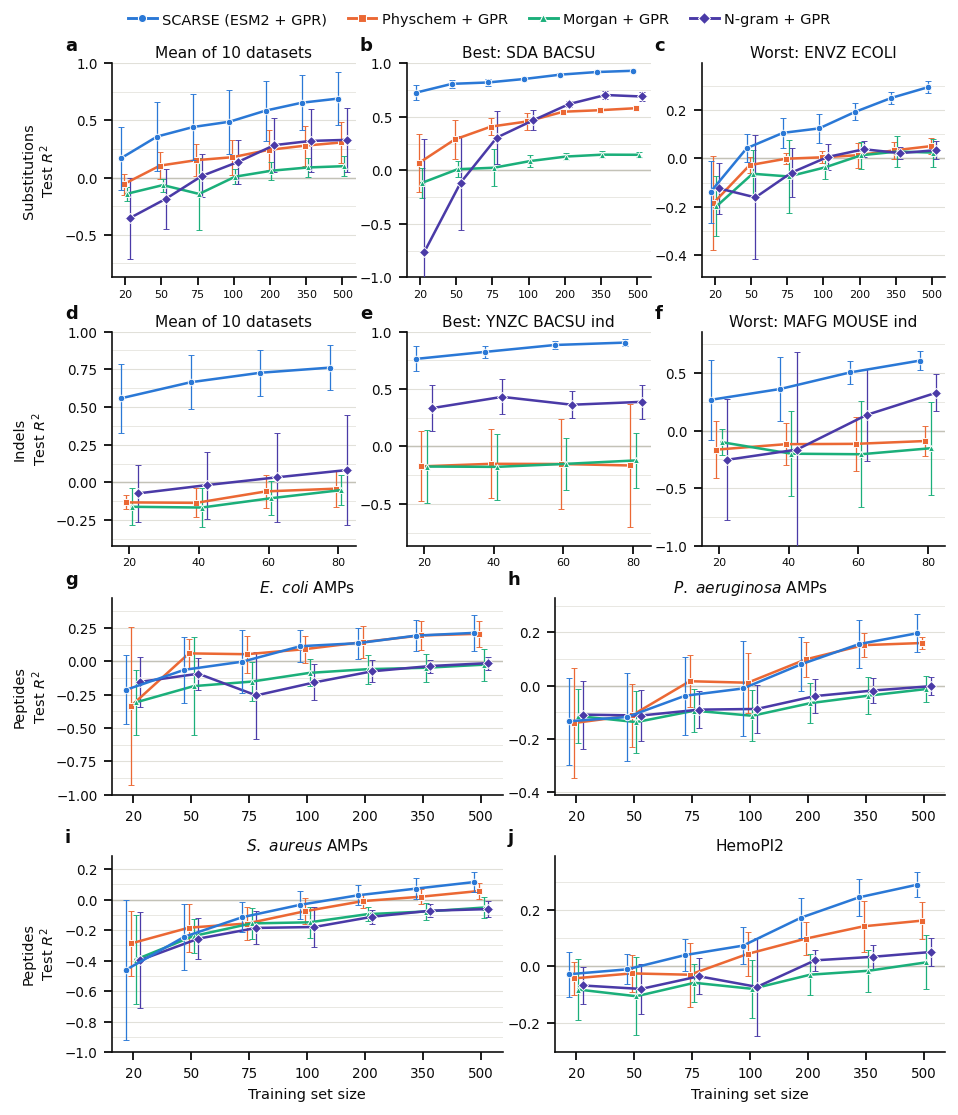

In [16]:
def rank_by_scarse(df):
    """Datasets ordered by SCARSE's mean over all training sizes, best first."""
    s = (df[df["Model Label"] == REFERENCE]
         .groupby("Dataset")["mean"].mean()
         .sort_values(ascending=False))
    return s


def plot_family_summary(metric="Test R2", ylabel=r"Test $R^2$",
                        families=("substitutions", "indels"), per_dataset=("peptides",),
                        row_h=2.0, stem="benchmark_results"):
    """Summary figure.

    Families in `families` get one row: mean over datasets | SCARSE's best |
    SCARSE's worst. Families in `per_dataset` are small enough to show every
    dataset on its own, two panels per row.
    """
    split = {f: sorted(load_processed(f, metric)["Dataset"].unique(),
                       key=lambda d: DATASET_SHORT.get(f, {}).get(d, d))
             for f in per_dataset}
    n_rows = len(families) + sum(int(np.ceil(len(d) / 2)) for d in split.values())
    fig = plt.figure(layout="constrained", figsize=(PAGE_WIDTH, row_h * n_rows + 0.45))
    tight_layout_pads(fig)
    # Two sub-figures, each laid out on its own: three-panel rows on top, two-panel
    # rows below. One shared grid would make the tick labels of one block push
    # gaps into the other.
    n_top = len(families)
    top, bottom = fig.subfigures(2, 1, height_ratios=[n_top, n_rows - n_top], hspace=0)
    gs_top = top.add_gridspec(n_top, 3)
    gs_bot = bottom.add_gridspec(n_rows - n_top, 2)
    k, row = 0, 0
    all_axes = []

    def finish(ax, title, first_in_row, fam, narrow=False):
        ax.set_title(title, pad=3)
        if narrow:             # three panels to a row: keep long tick rows apart
            ax.tick_params(axis="x", labelsize=6.2, pad=2)
        if first_in_row:
            ax.set_ylabel(f"{FAMILY_TITLE[fam]}\n{ylabel}")
        nonlocal k
        panel_letter(ax, k)
        k += 1
        all_axes.append((row, ax))

    for family in families:
        df = load_processed(family, metric)
        short = DATASET_SHORT.get(family, {})
        train_sizes = sorted(df["Train Size"].unique())
        x = np.arange(len(train_sizes))
        ranking = rank_by_scarse(df)
        best, worst = ranking.index[0], ranking.index[-1]

        # ---- mean across datasets, datasets as the unit
        ax = top.add_subplot(gs_top[row, 0])
        per_ds = df.pivot_table(index=["Dataset", "Train Size"], columns="Model Label",
                                values="mean")
        for model in MODEL_ORDER:
            if model not in per_ds.columns:
                continue
            g = per_ds[model].groupby(level="Train Size").agg(["mean", "std"])
            g = g.reindex(train_sizes)
            band_line(ax, x, g["mean"].values, g["std"].values, model)
        ax.set_xticks(x)
        ax.set_xticklabels(train_sizes)
        fine_grid(ax)
        fit_y(ax, metric)
        zero_line(ax)
        finish(ax, f"Mean of {df['Dataset'].nunique()} datasets", True, family, narrow=True)

        # ---- SCARSE's best and worst dataset
        for c, (tag, dataset) in enumerate([("Best", best), ("Worst", worst)], start=1):
            ax = top.add_subplot(gs_top[row, c])
            draw_curves(ax, df, dataset, train_sizes, metric)
            finish(ax, f"{tag}: {short.get(dataset, dataset)}", False, family, narrow=True)
        row += 1

    for family, datasets in split.items():
        df = load_processed(family, metric)
        short = DATASET_SHORT.get(family, {})
        train_sizes = sorted(df["Train Size"].unique())
        for i, dataset in enumerate(datasets):
            c = i % 2
            ax = bottom.add_subplot(gs_bot[row - n_top, c])
            draw_curves(ax, df, dataset, train_sizes, metric)
            finish(ax, short.get(dataset, dataset), c == 0, family)
            if c == 1 or i == len(datasets) - 1:
                row += 1

    # x-axis title only on the panels with nothing below them
    last = max(r for r, _ in all_axes)
    for r, ax in all_axes:
        if r == last:
            ax.set_xlabel("Training set size")

    fig.legend(handles=model_handles(), loc="outside upper center",
               ncol=len(MODEL_ORDER), columnspacing=1.4, handletextpad=0.4)
    save(fig, stem)
    plt.show()
    return fig


_ = plot_family_summary()

### Summary across families — Test Spearman

The same layout for Test Spearman ρ; best and worst are ranked by SCARSE's mean
Spearman. Saved as *benchmark_results_spearman.png* / *.pdf*.

Saved benchmark_results_spearman.png / .pdf


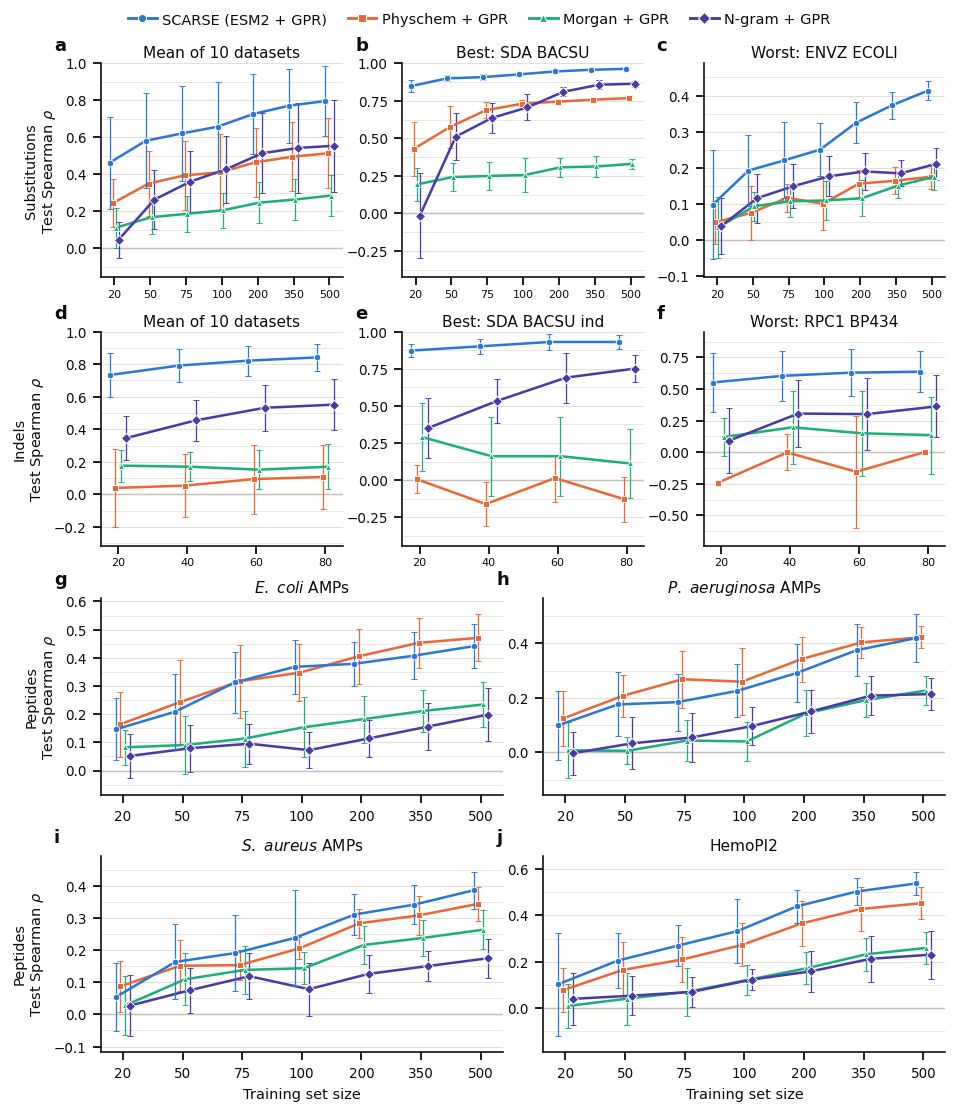

In [17]:
_ = plot_family_summary("Test Spearman Correlation", r"Test Spearman $\rho$",
                        stem="benchmark_results_spearman")

## Top-20 accuracy: substitutions overview and peptides

One figure for top-20 accuracy: the mean across all substitution datasets on
top (error bars ±1 SD across datasets), and each of the four peptide datasets
below in a 2×2 grid (error bars ±1 SD across seeds). Saved as
*benchmark_top20_sub_peptides.png* / *.pdf*.

Saved benchmark_top20_sub_peptides.png / .pdf


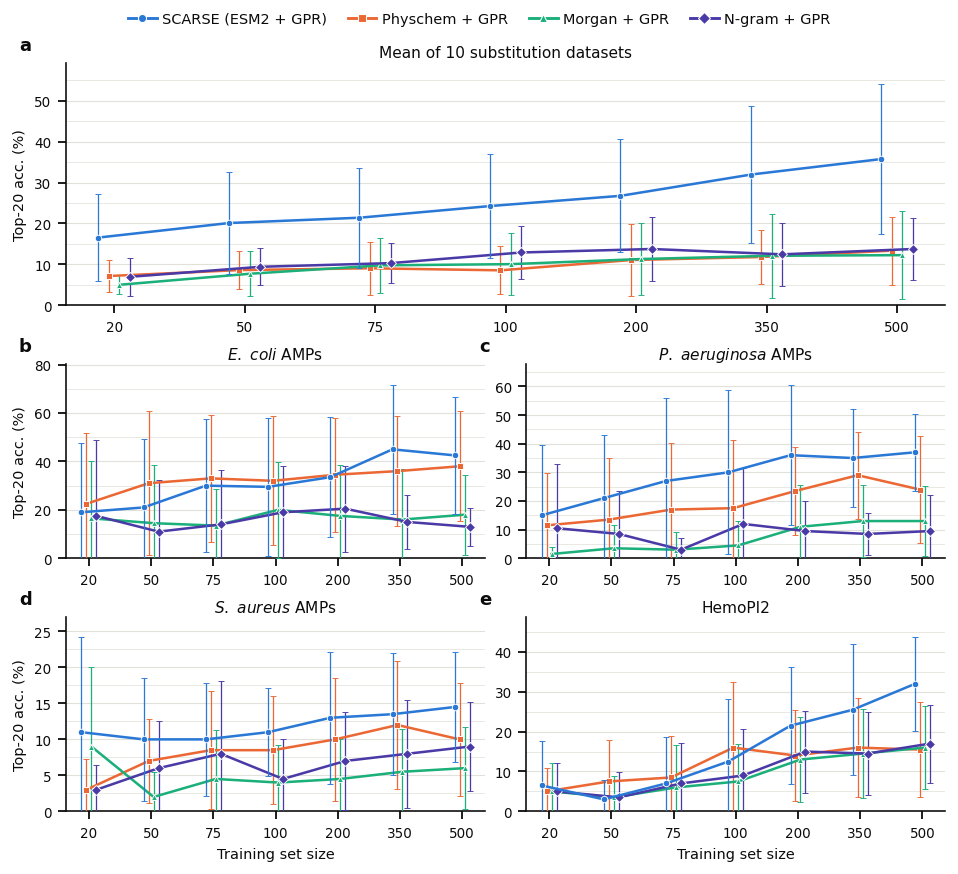

In [18]:
def plot_top20_sub_and_peptides(metric="Top 20 Accuracy", ylabel="Top-20 acc. (%)"):
    """Mean substitution dataset on top (full width), the four peptide datasets 2x2 below."""
    sub = load_processed("substitutions", metric)
    pep = load_processed("peptides", metric)
    pep_short = DATASET_SHORT.get("peptides", {})
    pep_datasets = sorted(pep["Dataset"].unique(), key=lambda d: pep_short.get(d, d))
    sub_sizes = sorted(sub["Train Size"].unique())
    pep_sizes = sorted(pep["Train Size"].unique())

    fig = plt.figure(layout="constrained", figsize=(PAGE_WIDTH, 6.6))
    tight_layout_pads(fig)
    # Top row spans both columns for the substitutions mean; 2x2 below for peptides.
    gs = fig.add_gridspec(3, 2, height_ratios=[1.25, 1.0, 1.0])
    k = 0

    # ---- mean across substitution datasets (datasets as the unit) ----
    ax = fig.add_subplot(gs[0, :])
    x = np.arange(len(sub_sizes))
    per_ds = sub.pivot_table(index=["Dataset", "Train Size"], columns="Model Label",
                             values="mean")
    for model in MODEL_ORDER:
        if model not in per_ds.columns:
            continue
        g = per_ds[model].groupby(level="Train Size").agg(["mean", "std"]).reindex(sub_sizes)
        band_line(ax, x, g["mean"].values, g["std"].values, model)
    ax.set_xticks(x); ax.set_xticklabels(sub_sizes)
    fine_grid(ax); fit_y(ax, metric); zero_line(ax)
    ax.set_title(f"Mean of {sub['Dataset'].nunique()} substitution datasets", pad=3)
    ax.set_ylabel(ylabel)
    panel_letter(ax, k); k += 1

    # ---- the four peptide datasets, 2x2 ----
    xp = np.arange(len(pep_sizes))
    for i, dataset in enumerate(pep_datasets):
        ax = fig.add_subplot(gs[1 + i // 2, i % 2])
        draw_curves(ax, pep, dataset, pep_sizes, metric)
        ax.set_title(pep_short.get(dataset, dataset), pad=3)
        if i % 2 == 0:
            ax.set_ylabel(ylabel)
        if i // 2 == 1:
            ax.set_xlabel("Training set size")
        panel_letter(ax, k); k += 1

    fig.legend(handles=model_handles(), loc="outside upper center",
               ncol=len(MODEL_ORDER), columnspacing=1.4, handletextpad=0.4)
    save(fig, "benchmark_top20_sub_peptides")
    plt.show()
    return fig


_ = plot_top20_sub_and_peptides()